# Relação entre Desenvolvimento Econômico, Condições Educacionais e Desempenho dos Participantes do ENEM nos Municípios Brasileiros

## Uma análise longitudinal de 2019 a 2023

Este é o único arquivo do relatório: reúne pergunta de pesquisa, hipóteses operacionais, método, código de agregação dos microdados, resultados, tabelas e gráficos recalculáveis. Execute as células em ordem em um kernel Python com `pandas`, `numpy` e `IPython` instalados. A consolidação já preparada é carregada automaticamente; a última seção contém o código completo para reconstruí-la dos arquivos fonte.

**Unidade de análise:** município onde a escola está localizada × ano. Os resultados descrevem associações municipais entre o PIB e resultados agregados observados no ENEM; não estimam efeitos causais nem relações individuais.

> Os arquivos em `dados/` são apenas lidos e permanecem intactos. A consolidação derivada é gravada em `resultados/municipio_ano.csv`.


## Pergunta de pesquisa

Como fatores econômicos, sociais e educacionais dos municípios brasileiros estão associados ao desempenho e à participação dos estudantes no ENEM entre 2019 e 2023, e de que maneira essas relações diferem entre as áreas do conhecimento e a redação?

### Objetivo geral

Investigar a associação entre características econômicas, sociais e educacionais dos municípios brasileiros e o desempenho e a participação agregados no ENEM, considerando as quatro provas objetivas, a redação, as diferenças regionais e a evolução temporal.

### Hipóteses operacionais neste recorte

1. PIB per capita mais alto está associado a médias municipais mais altas nas provas e na redação.
2. A associação com o PIB varia entre áreas, regiões e anos.
3. Municípios em diferentes posições econômicas apresentam trajetórias distintas de desempenho e comparecimento observado.
4. Dispersão das notas e proporção de redações com nota ≥800 variam com o contexto econômico.
5. A composição setorial do valor adicionado está associada a diferenças municipais de desempenho.

As 37 hipóteses do enunciado são organizadas nesses eixos para evitar uma coleção de testes isolados. Hipóteses sobre renda familiar, infraestrutura escolar, matrículas, aprovação/abandono e participação relativa da população são teoricamente pertinentes, mas não podem ser testadas com os arquivos fornecidos.


## Bases disponíveis e escopo observável

| Eixo | Arquivos encontrados | Operacionalização / limite |
|---|---|---|
| ENEM 2019–2023 | Microdados individuais do INEP, dicionários, itens e provas | Agregado por município da escola; notas e presenças por área |
| Economia municipal | PIB dos Municípios 2010–2023, IBGE | PIB per capita, PIB total e valores adicionados setoriais |
| Renda domiciliar | Não encontrada | Sem indicador municipal de renda disponível |
| Educação básica | Não foram encontrados arquivos do Censo Escolar nem taxas de rendimento | Sem infraestrutura, matrículas, docentes, dependências, aprovação, reprovação ou abandono |
| População elegível | Não encontrada | Não é possível estimar participação em relação à população que poderia prestar o ENEM |

Os dicionários e layouts do INEP foram conferidos para documentar as variáveis. Cadernos, gabaritos e arquivos de itens não são necessários para a agregação de presença e notas. Os dados ausentes não são inventados nem substituídos por aproximações sem base.


## Desenho, variáveis e decisões metodológicas

- **Chave territorial:** `CO_MUNICIPIO_ESC`, código do município de localização da escola. Não identifica necessariamente residência do participante nem local de aplicação.
- **Desfechos:** médias e desvios-padrão municipais das notas válidas de Ciências da Natureza (CN), Ciências Humanas (CH), Linguagens (LC), Matemática (MT) e redação (RED). A redação permanece separada.
- **Comparecimento:** presentes por área / inscritos com código municipal da escola. Para redação, usa-se presença em Linguagens, prova do mesmo dia. É comparecimento entre inscritos identificáveis, não cobertura da população elegível.
- **Economia:** PIB per capita é produção por residente, não renda familiar disponível. PIB e valores adicionados setoriais são nominais; comparação monetária entre anos não será interpretada como crescimento real sem deflator.
- **Associação:** Pearson mede associação linear e é sensível a extremos; Spearman mede associação monotônica por postos. Cada município tem peso igual na análise principal. Resultados ponderados por inscritos e filtrados por tamanho mínimo são sensibilidades, não substitutos da análise principal.
- **Incerteza:** intervalos bootstrap reamostram municípios dentro de cada ano (unidade independente assumida para esta aproximação). São intervalos exploratórios; não resolvem confundimento, dependência espacial nem seleção para o ENEM.
- **Quartis:** serão mostradas faixas anuais relativas e faixas fixadas pela posição de 2019. A segunda comparação acompanha grupos de origem, mas pode sofrer atrito de municípios sem nota em certos anos.
- **Período pandêmico:** 2020–2021 são marcados como contexto. Este desenho não identifica efeitos causais da pandemia.

Como o código municipal da escola falta em muitos registros, a base descreve apenas o subconjunto identificável. Mudanças na cobertura podem alterar comparações temporais.


## 1. Leitura e preparação da base municipal

A tabela consolidada foi gerada diretamente dos cinco arquivos de microdados do INEP e da planilha municipal do IBGE. A célula final contém o código integral para reconstruí-la sem carregar cada arquivo de vários gigabytes por inteiro na memória. Quando o CSV de resultados já existe, ele é reaproveitado para abrir o estudo rapidamente.


## 2. Cobertura, presenças e dados válidos

As contagens referem-se a candidatos com município da escola informado. A razão presentes/inscritos é exibida por área e deve ser lida somente como comparecimento entre esses registros. A tabela também apresenta o número de municípios observados, permitindo acompanhar mudanças de cobertura.


## 3. PIB per capita e notas nas cinco áreas

Comparamos Pearson e Spearman por ano, reportando número de municípios e intervalos bootstrap de 95% para Pearson. A figura de calor é gerada a partir dos coeficientes da tabela, então acompanha a base ao reexecutar o notebook.


## 4. Trajetórias por quartis de PIB per capita

As faixas anuais respondem como municípios em posições econômicas relativas se comportam em cada edição, mas sua composição pode mudar. Em paralelo, quartis definidos com o PIB de 2019 mantêm o grupo de origem constante. Todas as médias de grupo dão o mesmo peso a cada município observado; a tabela inclui o número de municípios por grupo-ano.


## 5. Diferenças regionais, dispersão e robustez

As associações regionais são calculadas dentro de cada macrorregião e não removem confundidores. Dispersão é o desvio-padrão entre notas válidas observadas em cada município; não é uma medida completa de desigualdade. A sensibilidade compara correlação não ponderada, ponderação pela quantidade de inscritos identificáveis e exclusão de municípios com menos de 30 registros.


## 6. Comparecimento, redações ≥800 e estrutura econômica

O corte de 800 pontos na redação é um limiar descritivo escolhido para explorar alto desempenho; não é classificação oficial de proficiência. As participações setoriais usam os quatro valores adicionados disponíveis e são comparadas dentro de cada ano. Como a planilha não inclui aqui todo o valor adicionado a preços constantes, essa composição não autoriza conclusões sobre crescimento real.


## 7. Síntese automática dos resultados

A síntese é calculada quando o notebook é executado. Ela resume sinais e magnitudes observados, sem converter associação em causalidade nem tratar significância estatística como importância substantiva.


## Limitações e dados que faltam para ampliar o estudo

1. **Falácia ecológica:** resultados municipais não descrevem a relação entre renda de uma pessoa e sua nota.
2. **Cobertura seletiva:** `CO_MUNICIPIO_ESC` ausente em muitos registros; as estatísticas são de uma fração identificável dos inscritos.
3. **Seleção:** os resultados são entre participantes com nota válida e não descrevem jovens que não prestaram o ENEM.
4. **Participação populacional:** requer denominador de população em idade elegível, compatível por município e ano.
5. **Confundimento:** renda domiciliar, escolaridade familiar, infraestrutura, matrículas e rendimento escolar não estão nas bases disponíveis.
6. **Composição das provas:** notas de edições diferentes podem refletir grupos e condições diferentes; nenhuma invariância de escala é assumida.
7. **Valores monetários:** séries setoriais estão em valores correntes; comparação temporal de montantes requer deflator adequado.
8. **Incerteza e dependência:** bootstrap municipal é aproximado e não corrige autocorrelação espacial, medidas repetidas ou fatores não observados.
9. **Pandemia:** período contextual, sem estratégia de identificação causal.

Para testar os eixos ampliados do enunciado, seriam necessários arquivos compatíveis do Censo Escolar, rendimento domiciliar e população elegível, com definições, níveis geográficos e anos documentados antes da junção.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display, SVG, Markdown
from IPython.display import HTML

ROOT = Path.cwd()
if not (ROOT / "dados").exists() and (ROOT.parent / "dados").exists():
    ROOT = ROOT.parent
CSV_PATH = ROOT / "resultados" / "municipio_ano.csv"
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Não encontrei {CSV_PATH}. Execute a célula final para processar os arquivos originais.")
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig", dtype={"codigo_municipio": str})
df["ano"] = df["ano"].astype(int)
AREAS = {"CN": "Ciências da Natureza", "CH": "Ciências Humanas", "LC": "Linguagens", "MT": "Matemática", "RED": "Redação"}
ANOS = sorted(df["ano"].dropna().unique())
if "RED_presentes" in df and "LC_presentes" in df:
    # Presença na redação ocorre no mesmo dia de Linguagens; o número de notas válidas é outro denominador.
    df["RED_presentes"] = df["LC_presentes"]
print(f"{len(df):,} linhas; {df['codigo_municipio'].nunique():,} códigos municipais; anos {ANOS[0]}–{ANOS[-1]}".replace(",", "."))
print("Colunas disponíveis:", ", ".join(df.columns))

def fmt_int(v):
    return f"{int(v):,}".replace(",", ".")

def corr_pair(g, x, y, method="pearson", weights=None):
    p = g[[x, y]].copy()
    if weights is not None:
        p["_w"] = weights
    p = p.replace([np.inf, -np.inf], np.nan).dropna()
    if len(p) < 3 or p[x].nunique() < 2 or p[y].nunique() < 2:
        return np.nan
    if method == "spearman":
        return p[x].corr(p[y], method="spearman")
    if weights is None:
        return p[x].corr(p[y])
    w = p["_w"].to_numpy(dtype=float)
    w = np.where(np.isfinite(w) & (w > 0), w, 0)
    if w.sum() == 0:
        return np.nan
    xval, yval = p[x].to_numpy(), p[y].to_numpy()
    mx, my = np.average(xval, weights=w), np.average(yval, weights=w)
    cov = np.average((xval-mx)*(yval-my), weights=w)
    den = np.sqrt(np.average((xval-mx)**2, weights=w)*np.average((yval-my)**2, weights=w))
    return cov/den if den else np.nan

def pearson_bootstrap(g, x, y, reps=400, seed=2026):
    p = g[[x,y]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(p) < 10:
        return np.nan, np.nan, np.nan
    xv, yv = p[x].to_numpy(float), p[y].to_numpy(float)
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(reps):
        ix = rng.integers(0, len(p), len(p))
        a, b = xv[ix], yv[ix]
        if np.std(a) > 0 and np.std(b) > 0:
            vals.append(np.corrcoef(a,b)[0,1])
    lo, hi = np.quantile(vals,[.025,.975]) if vals else (np.nan,np.nan)
    return np.corrcoef(xv,yv)[0,1], lo, hi

def svg_heatmap(frame, title, width=820, height=340):
    rows, cols = list(frame.index), list(frame.columns)
    left, top, cw, ch = 205, 65, 105, 43
    pieces = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">', '<rect width="100%" height="100%" fill="white"/>', '<style>text{font-family:Arial,sans-serif;fill:#18243a}.t{font-size:17px;font-weight:bold}.l{font-size:12px}.v{font-size:14px;font-weight:bold}</style>', f'<text x="16" y="25" class="t">{title}</text>']
    for j,c in enumerate(cols):
        pieces.append(f'<text x="{left+j*cw+cw/2}" y="52" text-anchor="middle" class="l">{c}</text>')
    for i,r in enumerate(rows):
        y=top+i*ch
        pieces.append(f'<text x="{left-10}" y="{y+27}" text-anchor="end" class="l">{r}</text>')
        for j,c in enumerate(cols):
            v=frame.loc[r,c]
            if pd.isna(v):
                fill="#eeeeee"; label="—"
            else:
                z=float(np.clip(v,-1,1)); red=int(245-100*max(z,0)); green=int(246-85*abs(z)); blue=int(250-20*max(-z,0)); fill=f'rgb({red},{green},{blue})'; label=f'{z:.2f}'
            pieces.append(f'<rect x="{left+j*cw+2}" y="{y}" width="{cw-4}" height="{ch-3}" rx="4" fill="{fill}"/>')
            pieces.append(f'<text x="{left+j*cw+cw/2}" y="{y+25}" text-anchor="middle" class="v">{label}</text>')
    pieces.append('</svg>')
    return SVG(''.join(pieces))

def svg_lines(frame, xcol, ycol, groupcol, title, ylabel, width=820, height=430):
    colors={"Q1":"#2672b8","Q2":"#43a482","Q3":"#e49a2f","Q4":"#c94c4c"}
    left,right,top,bottom=75,width-35,48,height-75
    xmin,xmax=float(frame[xcol].min()),float(frame[xcol].max())
    ymin,ymax=float(frame[ycol].min()),float(frame[ycol].max())
    pad=(ymax-ymin)*.12 or 1
    ymin-=pad; ymax+=pad
    sx=lambda x:left+(float(x)-xmin)/(xmax-xmin or 1)*(right-left)
    sy=lambda y:bottom-(float(y)-ymin)/(ymax-ymin)*(bottom-top)
    p=[f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">','<rect width="100%" height="100%" fill="white"/>','<style>text{font-family:Arial,sans-serif;fill:#18243a;font-size:12px}.title{font-size:17px;font-weight:bold}</style>',f'<text x="16" y="25" class="title">{title}</text>']
    for tick in np.linspace(ymin,ymax,5):
        yy=sy(tick); p.append(f'<line x1="{left}" y1="{yy:.1f}" x2="{right}" y2="{yy:.1f}" stroke="#e5e7eb"/><text x="{left-8}" y="{yy+4:.1f}" text-anchor="end">{tick:.0f}</text>')
    for year in sorted(frame[xcol].unique()):
        xx=sx(year); p.append(f'<text x="{xx:.1f}" y="{bottom+23}">{int(year)}</text>')
    for group,g in frame.groupby(groupcol,observed=True):
        g=g.sort_values(xcol); color=colors.get(str(group),"#2672b8")
        pts=' '.join(f'{sx(r[xcol]):.1f},{sy(r[ycol]):.1f}' for _,r in g.iterrows())
        p.append(f'<polyline points="{pts}" fill="none" stroke="{color}" stroke-width="3"/>')
        for _,r in g.iterrows(): p.append(f'<circle cx="{sx(r[xcol]):.1f}" cy="{sy(r[ycol]):.1f}" r="4" fill="{color}"/>')
    legend_y=height-20
    for i,group in enumerate(frame[groupcol].dropna().unique()):
        x=left+i*150;color=colors.get(str(group),"#2672b8")
        p.append(f'<line x1="{x}" y1="{legend_y-4}" x2="{x+20}" y2="{legend_y-4}" stroke="{color}" stroke-width="3"/><text x="{x+25}" y="{legend_y}">{group}</text>')
    p.append(f'<text transform="translate(18 {(top+bottom)/2}) rotate(-90)" text-anchor="middle">{ylabel}</text></svg>')
    return SVG(''.join(p))


27.850 linhas; 5.570 códigos municipais; anos 2019–2023
Colunas disponíveis: ano, codigo_municipio, municipio, uf, regiao, registrados, presentes_alguma, CN_inscritos, CN_presentes, CN_media, CN_desvio_padrao, CN_proporcao_nota_800_mais, CH_inscritos, CH_presentes, CH_media, CH_desvio_padrao, CH_proporcao_nota_800_mais, LC_inscritos, LC_presentes, LC_media, LC_desvio_padrao, LC_proporcao_nota_800_mais, MT_inscritos, MT_presentes, MT_media, MT_desvio_padrao, MT_proporcao_nota_800_mais, RED_inscritos, RED_presentes, RED_media, RED_desvio_padrao, RED_proporcao_nota_800_mais, pib_mil_reais, pib_per_capita_reais, va_agro_mil_reais, va_industria_mil_reais, va_servicos_mil_reais, va_administracao_mil_reais


### Cobertura por ano

`Municípios pareados` exige PIB per capita e pelo menos uma média de prova disponível. A razão de presença é um indicador de comparecimento entre os inscritos identificáveis.

In [2]:
cobertura = []
for ano, grupo in df.groupby("ano"):
    pareados = grupo[grupo["pib_per_capita_reais"].notna() & grupo[[f"{a}_media" for a in AREAS]].notna().any(axis=1)]
    linha = {"Ano": ano, "Municípios com ENEM e PIB": pareados["codigo_municipio"].nunique(),
             "Inscritos identificáveis": grupo["registrados"].fillna(0).sum()}
    for area, nome in AREAS.items():
        ins = grupo[f"{area}_inscritos"].fillna(0).sum()
        pres = grupo[f"{area}_presentes"].fillna(0).sum()
        linha[f"Presença {nome} (%)"] = 100*pres/ins if ins else np.nan
    cobertura.append(linha)
display(pd.DataFrame(cobertura).set_index("Ano").round(1))


,Municípios com ENEM e PIB,Inscritos identificáveis,Presença Ciências da Natureza (%),Presença Ciências Humanas (%),Presença Linguagens (%),Presença Matemática (%),Presença Redação (%)
Ano,,,,,,,
2019,5539,1147387,83.3,87.2,87.2,83.3,87.2
2020,5439,904569,59.6,62.4,62.4,59.6,62.4
2021,5488,813806,74.3,77.8,77.8,74.3,77.8
2022,5504,951944,73.0,76.6,76.6,73.0,76.6
2023,5494,958506,75.6,78.5,78.5,75.6,78.5


### Correlações anuais por área

In [3]:
correlacoes_pearson, correlacoes_spearman, n_pares, intervalos = [], [], [], []
for ano, grupo in df.groupby("ano"):
    lp, ls, ln, li = {"Ano":ano}, {"Ano":ano}, {"Ano":ano}, {"Ano":ano}
    for area,nome in AREAS.items():
        g=grupo[["pib_per_capita_reais",f"{area}_media"]].dropna()
        lp[nome]=corr_pair(g,"pib_per_capita_reais",f"{area}_media")
        ls[nome]=corr_pair(g,"pib_per_capita_reais",f"{area}_media",method="spearman")
        ln[nome]=len(g)
        r,lo,hi=pearson_bootstrap(g,"pib_per_capita_reais",f"{area}_media",seed=2026+ano+len(nome))
        li[nome]=f"{r:.3f} [{lo:.3f}; {hi:.3f}]" if np.isfinite(r) else "—"
    correlacoes_pearson.append(lp); correlacoes_spearman.append(ls); n_pares.append(ln); intervalos.append(li)
correlacoes=pd.DataFrame(correlacoes_pearson).set_index("Ano")
spearman=pd.DataFrame(correlacoes_spearman).set_index("Ano")
display(Markdown("**Pearson:** associação linear entre PIB per capita e nota média municipal.")); display(correlacoes.round(3))
display(Markdown("**Spearman:** associação monotônica por postos, menos sensível a extremos.")); display(spearman.round(3))
display(Markdown("**Pearson e IC bootstrap de 95% (municípios reamostrados):**")); display(pd.DataFrame(intervalos).set_index("Ano"))
display(pd.DataFrame(n_pares).set_index("Ano").rename_axis("Ano").round(0))


**Pearson:** associação linear entre PIB per capita e nota média municipal.

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Ano,,,,,
2019,0.292,0.306,0.335,0.278,0.171
2020,0.219,0.223,0.245,0.236,0.102
2021,0.190,0.182,0.177,0.182,0.094
2022,0.165,0.180,0.201,0.168,0.086
2023,0.191,0.200,0.217,0.189,0.061


**Spearman:** associação monotônica por postos, menos sensível a extremos.

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Ano,,,,,
2019,0.521,0.545,0.576,0.501,0.324
2020,0.432,0.453,0.479,0.452,0.251
2021,0.395,0.396,0.394,0.385,0.209
2022,0.359,0.397,0.426,0.388,0.221
2023,0.411,0.409,0.434,0.386,0.189


**Pearson e IC bootstrap de 95% (municípios reamostrados):**

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Ano,,,,,
2019,0.292 [0.257; 0.325],0.306 [0.267; 0.346],0.335 [0.298; 0.371],0.278 [0.240; 0.312],0.171 [0.141; 0.200]
2020,0.219 [0.190; 0.246],0.223 [0.198; 0.252],0.245 [0.214; 0.279],0.236 [0.207; 0.269],0.102 [0.075; 0.126]
2021,0.190 [0.167; 0.222],0.182 [0.159; 0.213],0.177 [0.153; 0.204],0.182 [0.157; 0.211],0.094 [0.072; 0.116]
2022,0.165 [0.135; 0.194],0.180 [0.153; 0.208],0.201 [0.174; 0.228],0.168 [0.144; 0.196],0.086 [0.061; 0.109]
2023,0.191 [0.162; 0.219],0.200 [0.174; 0.234],0.217 [0.188; 0.249],0.189 [0.157; 0.218],0.061 [0.034; 0.089]


,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Ano,,,,,
2019,5538,5539,5539,5538,5539
2020,5425,5439,5439,5425,5439
2021,5479,5486,5486,5479,5486
2022,5492,5504,5504,5492,5504
2023,5481,5494,5494,5481,5494


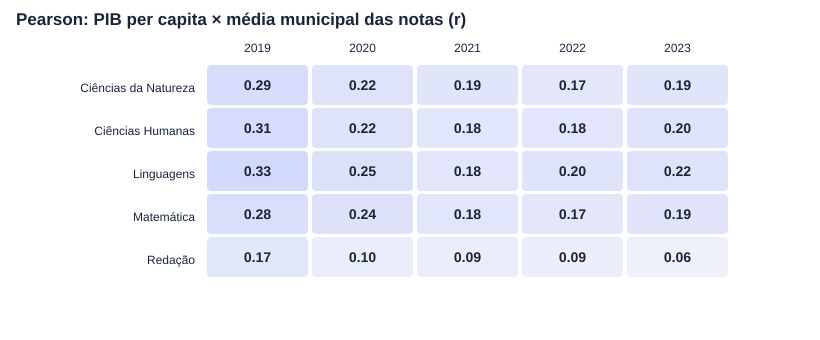

In [4]:
display(svg_heatmap(correlacoes.T, "Pearson: PIB per capita × média municipal das notas (r)"))


### Quartis anuais de PIB per capita

In [5]:
def quartil_ano(s):
    ranks=s.rank(method="first",pct=True)
    return pd.cut(ranks,bins=[0,.25,.50,.75,1.000001],labels=["Q1","Q2","Q3","Q4"],include_lowest=True)

df["quartil_pib_anual"]=df.groupby("ano")["pib_per_capita_reais"].transform(quartil_ano)
base2019=df.loc[df["ano"]==min(ANOS),["codigo_municipio","pib_per_capita_reais"]].dropna()
base2019["quartil_pib_2019"]=quartil_ano(base2019["pib_per_capita_reais"])
df=df.merge(base2019[["codigo_municipio","quartil_pib_2019"]],on="codigo_municipio",how="left")

def resumir_quartis(grupo_col,nota):
    return (df.dropna(subset=[grupo_col,nota]).groupby(["ano",grupo_col],observed=True)
            .agg(media_municipal=(nota,"mean"),municipios=("codigo_municipio","nunique")).reset_index())

quartis_redacao_anual=resumir_quartis("quartil_pib_anual","RED_media")
quartis_redacao_base=resumir_quartis("quartil_pib_2019","RED_media")
display(Markdown("**Quartis anuais — nota média e municípios observados:**"))
display(quartis_redacao_anual.pivot(index="ano",columns="quartil_pib_anual",values="media_municipal").round(1))
display(Markdown("Municípios observados em cada grupo e ano:"))
display(quartis_redacao_anual.pivot(index="ano",columns="quartil_pib_anual",values="municipios").fillna(0).astype(int))
display(Markdown("**Quartis fixos pela posição de PIB em 2019 — nota média e municípios observados:**"))
display(quartis_redacao_base.pivot(index="ano",columns="quartil_pib_2019",values="media_municipal").round(1))
display(Markdown("Municípios observados em cada grupo e ano:"))
display(quartis_redacao_base.pivot(index="ano",columns="quartil_pib_2019",values="municipios").fillna(0).astype(int))


**Quartis anuais — nota média e municípios observados:**

quartil_pib_anual,Q1,Q2,Q3,Q4
ano,,,,
2019,504.2,528.6,543.1,557.0
2020,502.8,533.7,548.6,556.9
2021,536.1,550.3,568.6,576.8
2022,528.4,551.0,574.6,576.3
2023,540.1,566.3,584.4,583.0


Municípios observados em cada grupo e ano:

quartil_pib_anual,Q1,Q2,Q3,Q4
ano,,,,
2019,1390,1387,1378,1384
2020,1384,1356,1346,1353
2021,1381,1367,1363,1375
2022,1383,1379,1364,1378
2023,1383,1375,1364,1372


**Quartis fixos pela posição de PIB em 2019 — nota média e municípios observados:**

quartil_pib_2019,Q1,Q2,Q3,Q4
ano,,,,
2019,504.2,528.6,543.1,557.0
2020,504.8,529.8,545.7,561.7
2021,534.0,548.2,567.1,582.6
2022,526.1,549.0,571.0,584.1
2023,539.7,562.3,580.1,591.5


Municípios observados em cada grupo e ano:

quartil_pib_2019,Q1,Q2,Q3,Q4
ano,,,,
2019,1390,1387,1378,1384
2020,1384,1354,1346,1355
2021,1382,1367,1364,1373
2022,1385,1377,1365,1377
2023,1381,1373,1370,1370


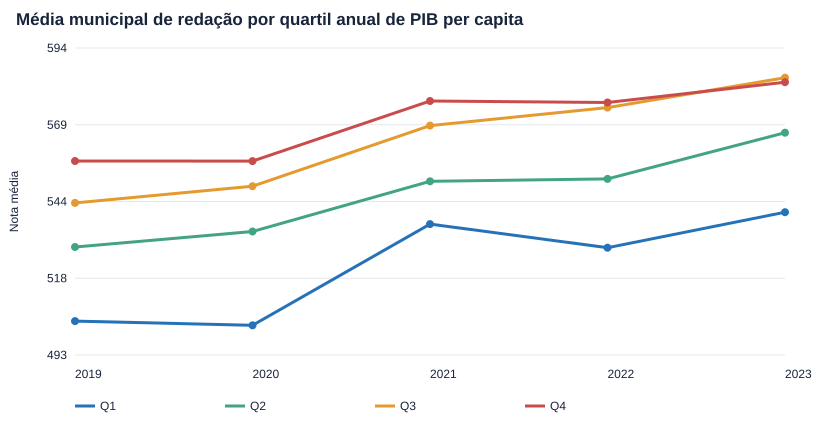

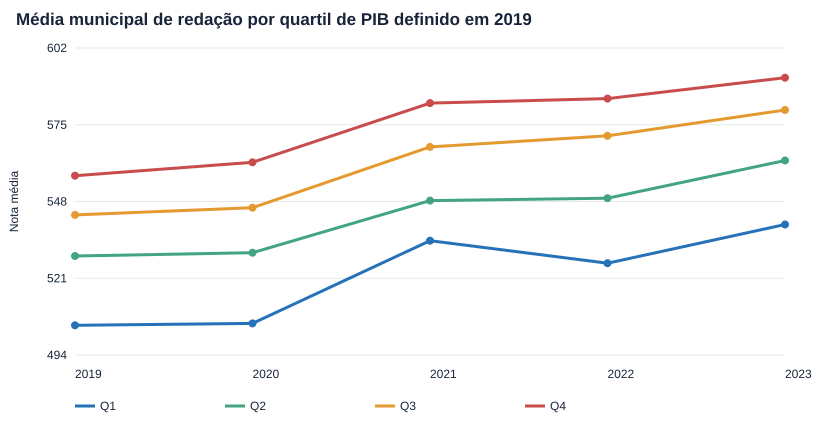

In [6]:
display(svg_lines(quartis_redacao_anual.rename(columns={"quartil_pib_anual":"Grupo"}),"ano","media_municipal","Grupo","Média municipal de redação por quartil anual de PIB per capita","Nota média"))
display(svg_lines(quartis_redacao_base.rename(columns={"quartil_pib_2019":"Grupo"}),"ano","media_municipal","Grupo","Média municipal de redação por quartil de PIB definido em 2019","Nota média"))


### Associações regionais no último ano disponível

In [7]:
ano_final=int(df["ano"].max())
regional=df[df["ano"]==ano_final].groupby("regiao",dropna=True)
linhas=[]
for regiao,grupo in regional:
    linha={"Região":regiao,"Municípios":grupo["codigo_municipio"].nunique()}
    for area,nome in AREAS.items(): linha[nome]=corr_pair(grupo,"pib_per_capita_reais",f"{area}_media")
    linhas.append(linha)
display(Markdown(f"**Correlações em {ano_final}, calculadas dentro de cada macrorregião:**"))
display(pd.DataFrame(linhas).set_index("Região").round(3))

dispersao=[]
for area,nome in AREAS.items():
    g=df[df["ano"]==ano_final]
    pares=g[["pib_per_capita_reais",f"{area}_desvio_padrao"]].dropna()
    dispersao.append({"Área":nome,"Municípios":len(pares),"Pearson: PIB × desvio-padrão":corr_pair(pares,"pib_per_capita_reais",f"{area}_desvio_padrao"),"Spearman":corr_pair(pares,"pib_per_capita_reais",f"{area}_desvio_padrao",method="spearman")})
display(Markdown(f"**Associação entre PIB per capita e dispersão intramunicipal das notas em {ano_final}:**"))
display(pd.DataFrame(dispersao).set_index("Área").round(3))


**Correlações em 2023, calculadas dentro de cada macrorregião:**

,Municípios,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Região,,,,,,
Centro-oeste,467,0.016,0.077,0.059,0.047,-0.079
Nordeste,1794,0.078,0.053,0.069,0.046,0.025
Norte,450,0.210,0.099,0.133,0.203,0.046
Sudeste,1668,0.094,0.120,0.135,0.106,0.050
Sul,1191,0.043,0.052,0.068,0.064,0.012


**Associação entre PIB per capita e dispersão intramunicipal das notas em 2023:**

,Municípios,Pearson: PIB × desvio-padrão,Spearman
Área,,,
Ciências da Natureza,5481,0.049,0.113
Ciências Humanas,5494,0.003,0.018
Linguagens,5494,-0.033,-0.073
Matemática,5481,0.084,0.193
Redação,5494,-0.109,-0.259


### Comparecimento observado, proporção de redações ≥800 e setores

In [8]:
resumo_extra=[]
for ano,grupo in df.groupby("ano"):
    g=grupo[grupo["pib_per_capita_reais"].notna()].copy()
    linha={"Ano":ano}
    for area,nome in AREAS.items():
        linha[f"r PIB × presença {nome}"]=corr_pair(g,"pib_per_capita_reais",f"{area}_presentes")
        linha[f"r PIB × presença relativa {nome}"]=corr_pair(g,"pib_per_capita_reais",f"{area}_presentes") if f"{area}_presentes" not in g else corr_pair(g.assign(_taxa=g[f"{area}_presentes"]/g[f"{area}_inscritos"].replace(0,np.nan)),"pib_per_capita_reais","_taxa")
    linha["r PIB × proporção redação ≥800"]=corr_pair(g,"pib_per_capita_reais","RED_proporcao_nota_800_mais")
    setor_cols=["va_agro_mil_reais","va_industria_mil_reais","va_servicos_mil_reais","va_administracao_mil_reais"]
    setor_total=g[setor_cols].sum(axis=1,min_count=1).replace(0,np.nan)
    rotulos=["Agropecuária","Indústria","Serviços","Administração pública"]
    for col,nome in zip(setor_cols,rotulos):
        share=g[col]/setor_total
        linha[f"r participação {nome} × redação"]=corr_pair(g.assign(_share=share),"_share","RED_media")
    resumo_extra.append(linha)
display(pd.DataFrame(resumo_extra).set_index("Ano").round(3))

# Variação municipal 2019–2023: associação exploratória, sem deflacionamento do PIB per capita nominal.
inicio=int(df["ano"].min()); fim=int(df["ano"].max())
base=df[df["ano"]==inicio].set_index("codigo_municipio")
final=df[df["ano"]==fim].set_index("codigo_municipio")
mudancas=[]
for area,nome in AREAS.items():
    p=pd.concat([base["pib_per_capita_reais"].rename("pib_ini"),final["pib_per_capita_reais"].rename("pib_fim"),
                 base[f"{area}_media"].rename("nota_ini"),final[f"{area}_media"].rename("nota_fim")],axis=1).dropna()
    p=p[(p["pib_ini"]>0)&(p["pib_fim"]>0)]
    p["variacao_log_pib_nominal"]=np.log(p["pib_fim"]/p["pib_ini"])
    p["variacao_nota"]=p["nota_fim"]-p["nota_ini"]
    mudancas.append({"Área":nome,"Municípios pareados":len(p),
        "r variação nominal PIB pc × variação nota":corr_pair(p,"variacao_log_pib_nominal","variacao_nota"),
        "rho (postos)":corr_pair(p,"variacao_log_pib_nominal","variacao_nota",method="spearman"),
        "Variação mediana da nota":p["variacao_nota"].median()})
display(Markdown(f"**Mudança de 2019 a {fim}:** associações entre variação nominal do PIB per capita (log da razão) e diferença na nota média municipal. Os valores monetários não foram deflacionados; esta comparação não mede crescimento real."))
display(pd.DataFrame(mudancas).set_index("Área").round(3))


,r PIB × presença Ciências da Natureza,r PIB × presença relativa Ciências da Natureza,r PIB × presença Ciências Humanas,r PIB × presença relativa Ciências Humanas,r PIB × presença Linguagens,r PIB × presença relativa Linguagens,r PIB × presença Matemática,r PIB × presença relativa Matemática,r PIB × presença Redação,r PIB × presença relativa Redação,r PIB × proporção redação ≥800,r participação Agropecuária × redação,r participação Indústria × redação,r participação Serviços × redação,r participação Administração pública × redação
Ano,,,,,,,,,,,,,,,
2019,0.069,-0.010,0.070,0.018,0.070,0.018,0.069,-0.010,0.070,0.018,0.059,-0.083,0.163,0.330,-0.314
2020,0.052,-0.001,0.052,0.002,0.052,0.002,0.052,-0.001,0.052,0.002,0.036,-0.142,0.147,0.338,-0.246
2021,0.034,0.031,0.034,0.032,0.034,0.032,0.034,0.031,0.034,0.032,0.016,-0.147,0.150,0.306,-0.216
2022,0.051,-0.032,0.052,-0.018,0.052,-0.018,0.051,-0.032,0.052,-0.018,0.016,NaN,NaN,NaN,NaN
2023,0.056,-0.028,0.056,-0.015,0.056,-0.015,0.056,-0.028,0.056,-0.015,-0.024,NaN,NaN,NaN,NaN


**Mudança de 2019 a 2023:** associações entre variação nominal do PIB per capita (log da razão) e diferença na nota média municipal. Os valores monetários não foram deflacionados; esta comparação não mede crescimento real.

,Municípios pareados,r variação nominal PIB pc × variação nota,rho (postos),Variação mediana da nota
Área,,,,
Ciências da Natureza,5459,-0.026,-0.022,19.350
Ciências Humanas,5472,0.006,-0.004,14.456
Linguagens,5472,-0.030,-0.042,-3.152
Matemática,5459,-0.060,-0.073,4.867
Redação,5472,-0.036,-0.036,42.222


### Sensibilidade a municípios pequenos e à ponderação

Comparamos associações não ponderadas com duas sensibilidades: ponderação pelo número de inscritos com município da escola identificado e exclusão de municípios com menos de 30 inscritos identificáveis. Os pesos não transformam a unidade em indivíduo; apenas mostram como a associação muda quando municípios maiores têm maior influência. O limite de 30 é uma escolha de sensibilidade e não um padrão oficial.


In [9]:
sensibilidade=[]
for ano,grupo in df.groupby("ano"):
    for area,nome in AREAS.items():
        g=grupo[["pib_per_capita_reais","registrados",f"{area}_media"]].dropna()
        if len(g)<3: continue
        sensibilidade.append({"Ano":ano,"Área":nome,"r municipal":corr_pair(g,"pib_per_capita_reais",f"{area}_media"),
            "r ponderado por inscritos":corr_pair(g,"pib_per_capita_reais",f"{area}_media",weights=g["registrados"]),
            "r excluindo <30 inscritos":corr_pair(g[g["registrados"]>=30],"pib_per_capita_reais",f"{area}_media"),
            "Municípios n≥30":int((g["registrados"]>=30).sum())})
sens_df=pd.DataFrame(sensibilidade)
display(sens_df[sens_df["Ano"]==ano_final].set_index("Área").round(3))


,Ano,r municipal,r ponderado por inscritos,r excluindo <30 inscritos,Municípios n≥30
Área,,,,,
Ciências da Natureza,2023,0.191,0.362,0.286,2981
Ciências Humanas,2023,0.200,0.376,0.291,2981
Linguagens,2023,0.217,0.399,0.309,2981
Matemática,2023,0.189,0.358,0.274,2981
Redação,2023,0.061,0.215,0.129,2981


## Síntese dos resultados observados

O bloco a seguir produz uma leitura automática, atualizada a cada execução, das associações de Pearson no ano mais recente. O texto é descritivo e deve ser interpretado junto dos intervalos, das sensibilidades e das limitações do desenho.


In [10]:
ano_final=int(correlacoes.index.max())
linha=correlacoes.loc[ano_final].dropna()
maior=linha.idxmax(); menor=linha.idxmin()
display(Markdown(f"**Em {ano_final},** a maior correlação linear PIB per capita–nota foi em **{maior}** (r={linha[maior]:.3f}) e a menor em **{menor}** (r={linha[menor]:.3f}). Esses coeficientes descrevem diferenças entre municípios observados e não controlam renda familiar, composição dos participantes, condições escolares ou outros fatores."))
print("Correlação por área ao longo do período:")
display(correlacoes.round(3))
print("Os intervalos bootstrap e a análise de sensibilidade acima mostram a incerteza amostral aproximada e a dependência em relação ao tamanho municipal. A análise disponível não permite concluir causalidade.")


**Em 2023,** a maior correlação linear PIB per capita–nota foi em **Linguagens** (r=0.217) e a menor em **Redação** (r=0.061). Esses coeficientes descrevem diferenças entre municípios observados e não controlam renda familiar, composição dos participantes, condições escolares ou outros fatores.

Correlação por área ao longo do período:


,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
Ano,,,,,
2019,0.292,0.306,0.335,0.278,0.171
2020,0.219,0.223,0.245,0.236,0.102
2021,0.190,0.182,0.177,0.182,0.094
2022,0.165,0.180,0.201,0.168,0.086
2023,0.191,0.200,0.217,0.189,0.061


Os intervalos bootstrap e a análise de sensibilidade acima mostram a incerteza amostral aproximada e a dependência em relação ao tamanho municipal. A análise disponível não permite concluir causalidade.


## Código integral de reconstrução dos dados

Se `resultados/municipio_ano.csv` não existir ou se desejar reconstruí-lo, altere `REPROCESSAR_MICRODADOS` para `True` e execute esta célula. O processamento lê os microdados em fluxo, ano a ano; os arquivos fonte dentro de `dados/` não são modificados. A operação pode levar bastante tempo e requer espaço para o CSV derivado.


In [11]:
# Por padrão, usa-se a consolidação já disponível. Troque para True para reler os arquivos brutos.
REPROCESSAR_MICRODADOS = False

if REPROCESSAR_MICRODADOS:
    import csv, gzip, math, re, zipfile
    from collections import defaultdict
    from xml.etree import ElementTree as ET

    DATA_DIR = ROOT / "dados"
    DATA_DIRS = [ROOT / "dados", ROOT / "dados_github"]
    OUTPUT = ROOT / "resultados" / "municipio_ano.csv"
    YEARS = range(2019, 2024)
    AREAS_RAW = {
        "CN": ("TP_PRESENCA_CN", "NU_NOTA_CN"),
        "CH": ("TP_PRESENCA_CH", "NU_NOTA_CH"),
        "LC": ("TP_PRESENCA_LC", "NU_NOTA_LC"),
        "MT": ("TP_PRESENCA_MT", "NU_NOTA_MT"),
        # A redação é aplicada no primeiro dia, junto com Linguagens.
        "RED": ("TP_PRESENCA_LC", "NU_NOTA_REDACAO"),
    }
    NS = {"m": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

    def number(value):
        try:
            n=float(value)
            return n if math.isfinite(n) else None
        except (TypeError,ValueError):
            return None

    def aggregate_enem(year):
        matches=[p for d in DATA_DIRS if d.exists() for p in d.rglob(f"MICRODADOS_ENEM_{year}.csv")]
        if not matches:
            matches=[p for d in DATA_DIRS if d.exists() for p in d.rglob(f"MICRODADOS_ENEM_{year}.csv.gz")]
        if len(matches)!=1:
            raise FileNotFoundError(f"Esperado um CSV ENEM {year} (ou cópia .csv.gz); encontrados {len(matches)}")
        groups=defaultdict(lambda:{"registrados":0,"presentes_alguma":0,
            **{f"{a}_{k}":0 for a in AREAS_RAW for k in ("inscritos","presentes","n_notas","soma","soma2","red_800")}})
        source=matches[0]
        opener=(gzip.open(source,"rt",encoding="latin1",newline="",errors="replace")
                if source.suffix==".gz" else source.open("r",encoding="latin1",newline="",errors="replace"))
        with opener as stream:
            reader=csv.DictReader(stream,delimiter=";")
            required={"CO_MUNICIPIO_ESC","TP_PRESENCA_CN","TP_PRESENCA_CH","TP_PRESENCA_LC","TP_PRESENCA_MT","NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT","NU_NOTA_REDACAO"}
            if not required.issubset(reader.fieldnames or []):
                raise ValueError(f"Colunas inesperadas em {matches[0].name}")
            for row in reader:
                code=(row.get("CO_MUNICIPIO_ESC") or "").strip()
                if not code.isdigit():
                    continue
                g=groups[code]
                g["registrados"]+=1
                any_present=False
                for area,(presence_col,score_col) in AREAS_RAW.items():
                    present=row.get(presence_col)=="1"
                    g[f"{area}_inscritos"]+=1
                    if present:
                        any_present=True
                        g[f"{area}_presentes"]+=1
                    score=number(row.get(score_col,""))
                    if present and score is not None:
                        g[f"{area}_n_notas"]+=1
                        g[f"{area}_soma"]+=score
                        g[f"{area}_soma2"]+=score*score
                        if area=="RED" and score>=800:
                            g["RED_red_800"]+=1
                if any_present:
                    g["presentes_alguma"]+=1
        return groups

    pib_files=list(DATA_DIR.rglob("PIB dos Munic*.xlsx"))
    if len(pib_files)!=1:
        raise FileNotFoundError(f"Esperada uma planilha PIB; encontradas {len(pib_files)}")
    with zipfile.ZipFile(pib_files[0]) as zf:
        strings=[]
        if "xl/sharedStrings.xml" in zf.namelist():
            root_xml=ET.fromstring(zf.read("xl/sharedStrings.xml"))
            strings=["".join(t.text or "" for t in si.findall(".//m:t",NS)) for si in root_xml.findall("m:si",NS)]
        sheet=ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))
        pib={}
        for row in sheet.findall(".//m:sheetData/m:row",NS):
            vals={}
            for cell in row.findall("m:c",NS):
                match=re.match(r"([A-Z]+)",cell.attrib["r"])
                col=match.group(1)
                v=cell.find("m:v",NS)
                value="" if v is None else v.text or ""
                if cell.attrib.get("t")=="s" and value:
                    value=strings[int(value)]
                vals[col]=value.strip()
            if row.attrib.get("r")=="1":
                continue
            try:
                year=int(float(vals.get("A",""))); code=vals.get("G","")
            except ValueError:
                continue
            if year not in YEARS or not code.isdigit():
                continue
            pib[(year,code)]={
                "pib_mil_reais":number(vals.get("AM","")),
                "pib_per_capita_reais":number(vals.get("AN","")),
                "va_agro_mil_reais":number(vals.get("AG","")),
                "va_industria_mil_reais":number(vals.get("AH","")),
                "va_servicos_mil_reais":number(vals.get("AI","")),
                "va_administracao_mil_reais":number(vals.get("AJ","")),
                "regiao":vals.get("C",""),"uf":vals.get("E",""),"municipio":vals.get("H","")}

    enem={}
    for year in YEARS:
        print(f"Agregando ENEM {year}: leitura integral do CSV",flush=True)
        enem[year]=aggregate_enem(year)
    fields=["ano","codigo_municipio","municipio","uf","regiao","registrados","presentes_alguma"]
    for area in AREAS_RAW:
        fields += [f"{area}_inscritos",f"{area}_presentes",f"{area}_media",f"{area}_desvio_padrao",f"{area}_proporcao_nota_800_mais"]
    fields += ["pib_mil_reais","pib_per_capita_reais","va_agro_mil_reais","va_industria_mil_reais","va_servicos_mil_reais","va_administracao_mil_reais"]
    OUTPUT.parent.mkdir(parents=True,exist_ok=True)
    with OUTPUT.open("w",encoding="utf-8-sig",newline="") as f:
        writer=csv.DictWriter(f,fieldnames=fields)
        writer.writeheader()
        keys=sorted({(year,code) for year in YEARS for code in enem[year]}|set(pib))
        for year,code in keys:
            g=enem.get(year,{}).get(code,{})
            out={"ano":year,"codigo_municipio":code,"registrados":g.get("registrados",0),"presentes_alguma":g.get("presentes_alguma",0)}
            out.update(pib.get((year,code),{}))
            for area in AREAS_RAW:
                n=g.get(f"{area}_n_notas",0)
                mean=g.get(f"{area}_soma",0)/n if n else None
                variance=max(0,g.get(f"{area}_soma2",0)/n-mean**2) if n else None
                pres=g.get(f"{area}_presentes",0)
                out.update({f"{area}_inscritos":g.get(f"{area}_inscritos",0),f"{area}_presentes":pres,
                    f"{area}_media":round(mean,4) if mean is not None else "",
                    f"{area}_desvio_padrao":round(math.sqrt(variance),4) if variance is not None else "",
                    f"{area}_proporcao_nota_800_mais":round(g.get("RED_red_800",0)/n,6) if area=="RED" and n else ""})
            writer.writerow({k:(out.get(k,"") if out.get(k) is not None else "") for k in fields})
    print(f"Consolidação concluída: {OUTPUT}")
else:
    print("Consolidação existente preservada. Para reconstruir, altere REPROCESSAR_MICRODADOS para True e execute esta célula.")


Consolidação existente preservada. Para reconstruir, altere REPROCESSAR_MICRODADOS para True e execute esta célula.
